In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import pandas as pd
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
    make_column_transformer,
)
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import make_scorer, root_mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
    RepeatedKFold,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

In [2]:
# Split into train and test
df = pd.read_csv("../Data/sales.csv")
df.head()

,type,likes,num_comments,num_shares,days_from_event,revenue,total_transactions,collab,date,num_posts,memberships_sold,pop,popcorn_large,popcorn_medium,popcorn_small,Alcohol,general_promo_likes,general_promo_shares,type_post,candy
0,Regular screening,291.0,7.0,141.0,2.0,472.46,95.0,No,04/09/2025,1,62.0,17.0,7.0,11.0,5.0,0.0,NaN,NaN,individual,0.0
1,Regular screening,222.0,4.0,118.0,2.0,598.42,108.0,No,08/09/2025,1,74.0,19.0,9.0,17.0,12.0,0.0,NaN,NaN,individual,0.0
2,Regular screening,228.0,11.0,129.0,2.0,633.93,128.0,No,11/09/2025,1,71.0,26.0,20.0,21.0,8.0,0.0,NaN,NaN,individual,0.0
3,Screen + Q&A,137.0,0.0,39.0,10.0,25.00,9.0,No,15/09/2025,2,3.0,3.0,1.0,0.0,1.0,0.0,89.0,33.0,both,0.0
4,Regular screening,194.0,0.0,41.0,2.0,237.92,53.0,No,18/09/2025,2,24.0,19.0,6.0,6.0,9.0,0.0,89.0,33.0,both,0.0


In [3]:
# Fill missing values with 0
df["general_promo_likes"] = df["general_promo_likes"].fillna(0)
df["general_promo_shares"] = df["general_promo_shares"].fillna(0)

# Covert date from string
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Date/month feature
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

# Sort
df_sorted = df.sort_values("date")

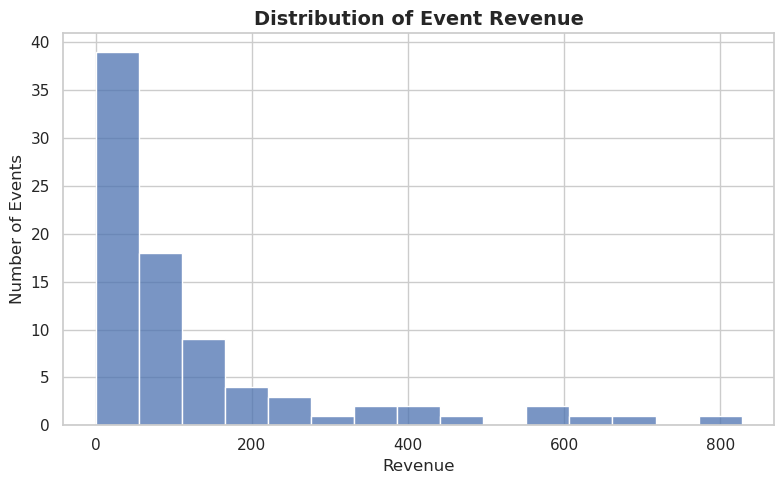

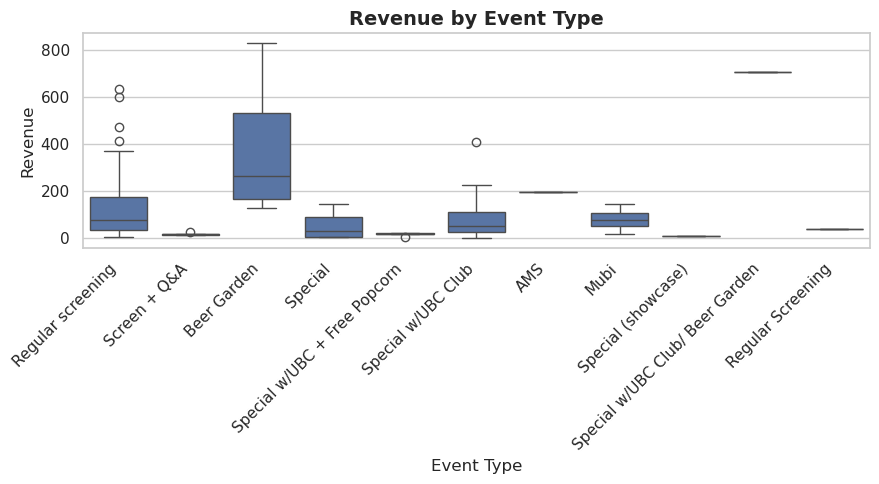

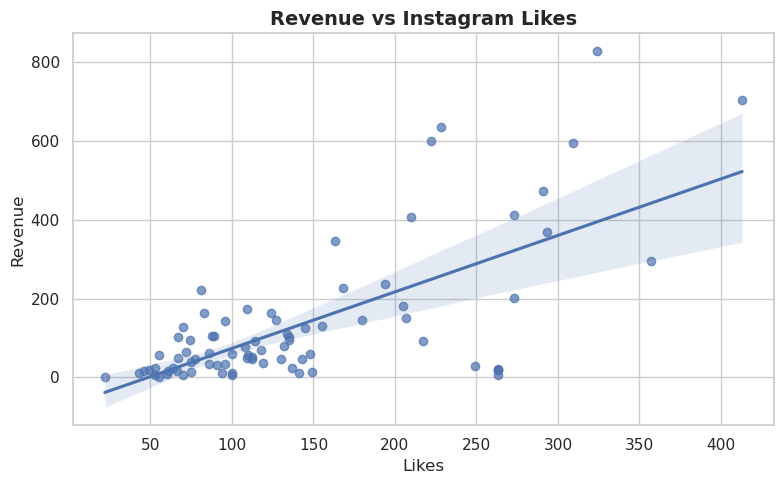

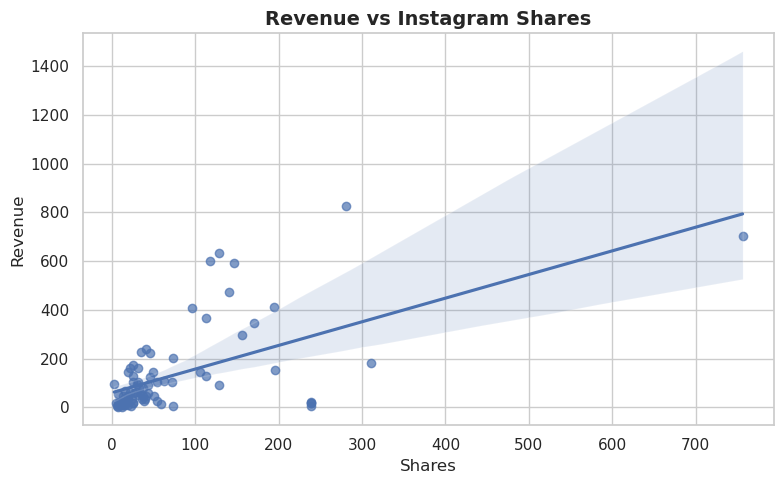

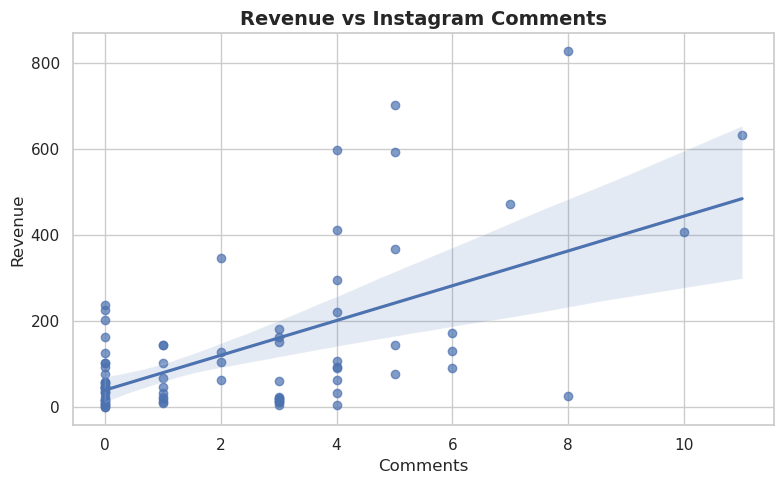

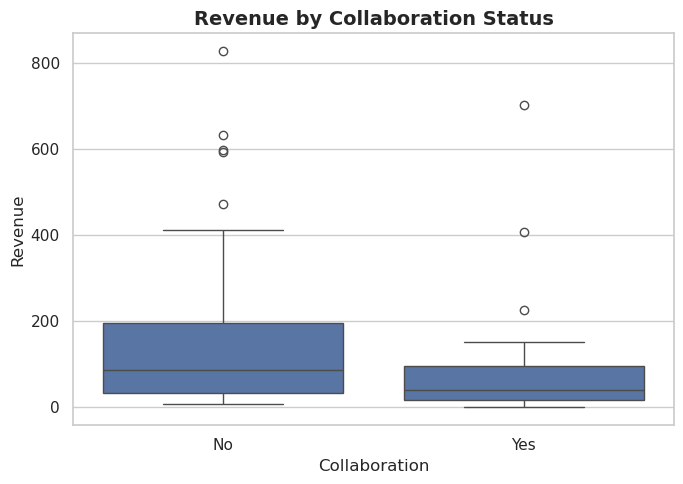

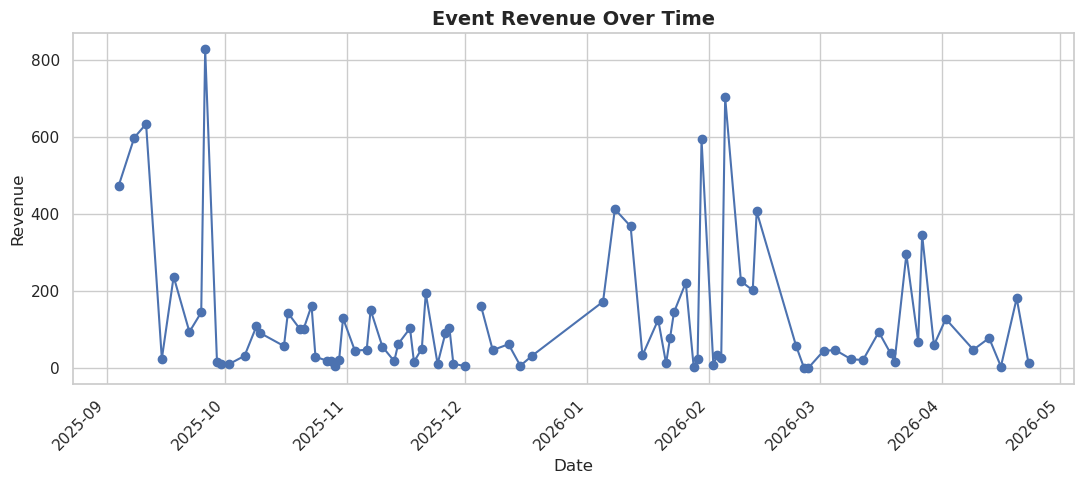

In [4]:
# EDA Visualizations
sns.set_theme(style="whitegrid")

def finish_plot(title, xlabel=None, ylabel=None, rotate_x=False):
    plt.title(title, fontsize=14, fontweight="bold")
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if rotate_x:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# 1. Revenue Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["revenue"], bins=15)
finish_plot(
    title="Distribution of Event Revenue",
    xlabel="Revenue",
    ylabel="Number of Events"
)


# 2. Revenue by Event Type
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="type", y="revenue")
finish_plot(
    title="Revenue by Event Type",
    xlabel="Event Type",
    ylabel="Revenue",
    rotate_x=True
)


# 3. Revenue vs Likes
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="likes", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Likes",
    xlabel="Likes",
    ylabel="Revenue"
)


# 4. Revenue vs Shares
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="num_shares", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Shares",
    xlabel="Shares",
    ylabel="Revenue"
)


# 5. Revenue vs Comments
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="num_comments", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Comments",
    xlabel="Comments",
    ylabel="Revenue"
)


# 6. Revenue by Collaboration
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="collab", y="revenue")
finish_plot(
    title="Revenue by Collaboration Status",
    xlabel="Collaboration",
    ylabel="Revenue"
)


# 7. Revenue Over Time
plt.figure(figsize=(11, 5))
plt.plot(df_sorted["date"], df_sorted["revenue"], marker="o")
finish_plot(
    title="Event Revenue Over Time",
    xlabel="Date",
    ylabel="Revenue",
    rotate_x=True
)

<Axes: >

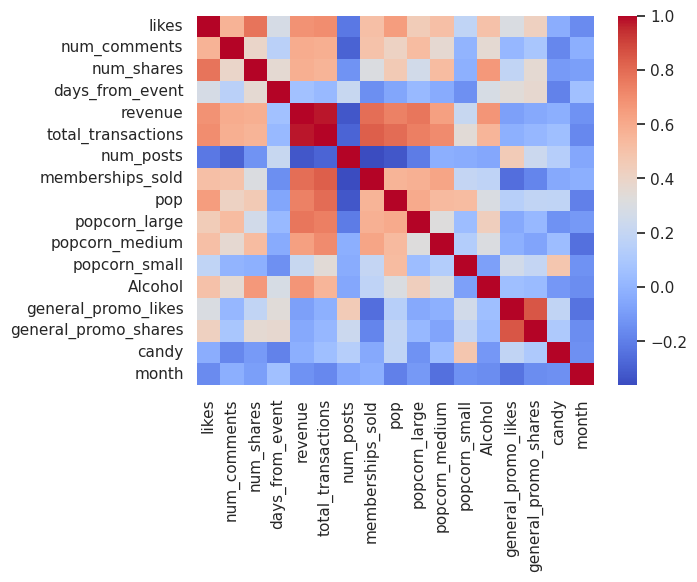

In [5]:
# Correlation mapping
numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

<Axes: xlabel='total_engagement', ylabel='revenue'>

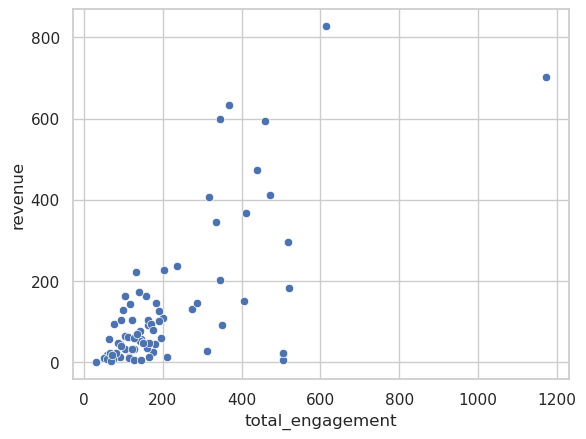

In [6]:
# Feature Engineering 
df["total_engagement"] = (
    df["likes"]
    + df["num_comments"]
    + df["num_shares"]
)

sns.scatterplot(
    data=df,
    x="total_engagement",
    y="revenue"
)

In [7]:
df = df.dropna(subset=["revenue"])

# Target
y = np.log1p(df["revenue"])

# Features
X = df.drop(columns=["revenue", "date"])

In [8]:
numeric_features = [
    "likes",
    "num_comments",
    "num_shares",
    "num_posts",
    "days_from_event",
    "general_promo_likes",
    "general_promo_shares"
]

categorical_features = [
    "type",
    "collab",
    "month",
    "day_of_week"
]

numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)

In [10]:
# Dummy Model

dummy = make_pipeline(
    preprocessor,
    DummyRegressor(strategy="mean")
)

cross_val_score(
    dummy,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
).mean()

np.float64(-0.02493388608552145)

In [11]:
# Baseline: Linear Regression

ridge_model = make_pipeline(
    preprocessor,
    RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
)

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=123
)

ridge_cv_scores = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

print("RidgeCV CV R² scores:", ridge_cv_scores)
print("RidgeCV mean CV R²:", ridge_cv_scores.mean())
print("RidgeCV std CV R²:", ridge_cv_scores.std())

RidgeCV CV R² scores: [-0.012316    0.06164386  0.60678421  0.23437088  0.24514931  0.31424782
  0.49441206  0.09868753  0.28010344  0.30591578 -1.12481312  0.12884868
  0.3327909   0.38720346  0.47185752 -1.30373962  0.40013476  0.53998739
  0.2760708   0.05936844  0.47471835  0.37216372  0.52587568  0.42937584
  0.28835263 -0.27836709  0.30286642  0.67547054  0.2961938   0.46507533
  0.08355486 -0.44251613  0.49589811  0.67835109 -0.40579617  0.58486012
  0.22541656  0.08545388  0.47982171  0.15964597  0.73102929 -0.14186796
  0.46493405  0.26117765  0.02702605  0.41029337  0.14678222  0.43816283
  0.31621906 -0.68068198]
RidgeCV mean CV R²: 0.20532395760944194
RidgeCV std CV R²: 0.4062571791590481


In [12]:
ridge_model.fit(X_train, y_train)

preds_log = ridge_model.predict(X_test)

actual_revenue = np.expm1(y_test)
predicted_revenue = np.expm1(preds_log)

print(
    "RidgeCV Test RMSE:",
    root_mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

print(
    "RidgeCV Test R²:",
    r2_score(
        actual_revenue,
        predicted_revenue
    )
)

RidgeCV Test RMSE: 104.55438349524118
RidgeCV Test R²: 0.481806690927715


In [13]:
# Random Forest
rf_model = make_pipeline(
    preprocessor,
    RandomForestRegressor(
        n_estimators=500,
        random_state=123
    )
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

print("RF CV R² Scores:")
print(rf_cv_scores)

print("\nMean CV R²:")
print(rf_cv_scores.mean())

print("\nStd CV R²:")
print(rf_cv_scores.std())

RF CV R² Scores:
[-0.34293056 -0.27442986  0.60757349  0.31663794  0.43878075  0.39279617
  0.49304839  0.50276457  0.15014781  0.51184896 -1.36158347 -0.12342836
  0.45076752  0.39625247  0.48927495 -1.71483796  0.05977055  0.21488438
  0.37059631  0.4321009   0.57702968  0.39181981  0.45618212  0.09476945
  0.60594989 -0.08921248  0.33854854  0.39840053  0.11573329  0.41253882
  0.0763494   0.12459265  0.4753794   0.65213516 -0.0490616   0.58244122
  0.39538893  0.20817402  0.3520625   0.06791158  0.49377923  0.14599729
  0.56823224  0.51214194  0.06454206  0.56228977  0.28094218  0.3577764
  0.39837428  0.1739355 ]

Mean CV R²:
0.2351035753142871

Std CV R²:
0.43020262869324016


In [14]:
rf_model.fit(X_train, y_train)

rf_preds_log = rf_model.predict(X_test)

actual_revenue = np.expm1(y_test)
predicted_revenue = np.expm1(rf_preds_log)

print(
    "RF Test RMSE:",
    root_mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

print(
    "RF Test R²:",
    r2_score(
        actual_revenue,
        predicted_revenue
    )
)

RF Test RMSE: 92.5015985577284
RF Test R²: 0.5943926782304638


In [15]:
# Comparison
results = pd.DataFrame({
    "Model": ["RidgeCV", "Random Forest"],
    "CV R²": [
        ridge_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "CV Std": [
        ridge_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

results

,Model,CV R²,CV Std
0,RidgeCV,0.205324,0.406257
1,Random Forest,0.235104,0.430203


In [16]:
# Feature Importances 
rf_model.fit(X_train, y_train)

result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=123,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
1,likes,0.254151
3,num_shares,0.119182
2,num_comments,0.057313
19,day_of_week,0.035325
14,general_promo_likes,0.018792
0,type,0.014943
4,days_from_event,0.013394
15,general_promo_shares,0.009985
6,collab,0.001433
11,popcorn_medium,0.000000


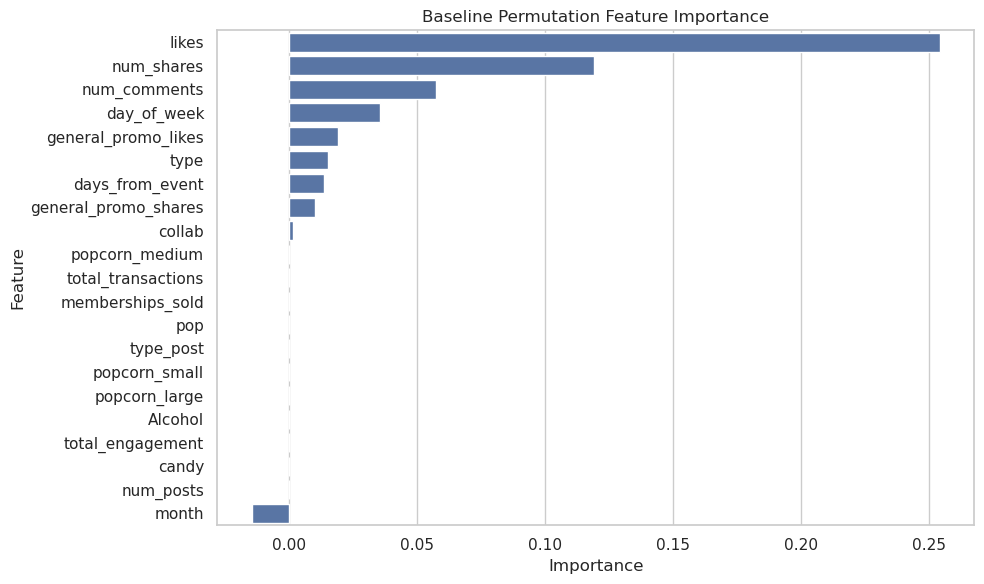

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)
plt.title("Baseline Permutation Feature Importance")
plt.tight_layout()
plt.show()